# Arabic Handwritten Digit Recognition - MLP Only

This Colab notebook uses a normal fully connected Neural Network / MLP for Arabic handwritten digit recognition.

Important rules followed:
- No `Conv2D`
- No `MaxPooling2D`
- Input shape stays `(28, 28, 1)`
- TFLite input shape should stay `[1, 28, 28, 1]`
- TFLite output shape should stay `[1, 10]`

## Why MLP Is Weaker Than CNN for Images

A normal Neural Network / MLP flattens the image from `28x28` into one long vector. This means it does not naturally understand nearby pixels, edges, strokes, or shapes.

A CNN is usually better for images because convolution layers learn local visual patterns. However, an MLP is still valid for this project requirement because the images are small, grayscale, centered digits, and the task has only 10 classes.

In [ ]:
# 1. Install libraries
!pip install -q datasets tensorflow opencv-python-headless scikit-learn seaborn matplotlib


In [ ]:
# 2. Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

from datasets import load_dataset
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [ ]:
# 3. Load MADBase dataset from Hugging Face
# Dataset link: https://huggingface.co/datasets/MagedSaeed/MADBase

dataset = load_dataset("MagedSaeed/MADBase")

train_dataset = dataset["train"]
test_dataset = dataset["test"]

print(train_dataset)
print(test_dataset)
print("Columns:", train_dataset.column_names)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-360de881cb44d5(…):   0%|          | 0.00/13.2M [00:00<?, ?B/s]

data/test-00000-of-00001-4fb8430c739afd6(…):   0%|          | 0.00/2.19M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/59999 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9999 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label'],
    num_rows: 59999
})
Dataset({
    features: ['image', 'label'],
    num_rows: 9999
})
Columns: ['image', 'label']


In [ ]:
# 4. Convert MADBase images and labels to NumPy arrays

def dataset_to_numpy(dataset_split):
    images = []
    labels = []

    for item in dataset_split:
        image = item["image"].convert("L")      # grayscale
        image = image.resize((28, 28))           # ensure 28x28
        image_array = np.array(image, dtype="float32")

        images.append(image_array)
        labels.append(item["label"])

    images = np.array(images, dtype="float32")
    labels = np.array(labels, dtype="int64")

    return images, labels

x_train, y_train = dataset_to_numpy(train_dataset)
x_test, y_test = dataset_to_numpy(test_dataset)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)
print("Labels:", np.unique(y_train))


x_train shape: (59999, 28, 28)
y_train shape: (59999,)
x_test shape: (9999, 28, 28)
y_test shape: (9999,)
Labels: [0 1 2 3 4 5 6 7 8 9]


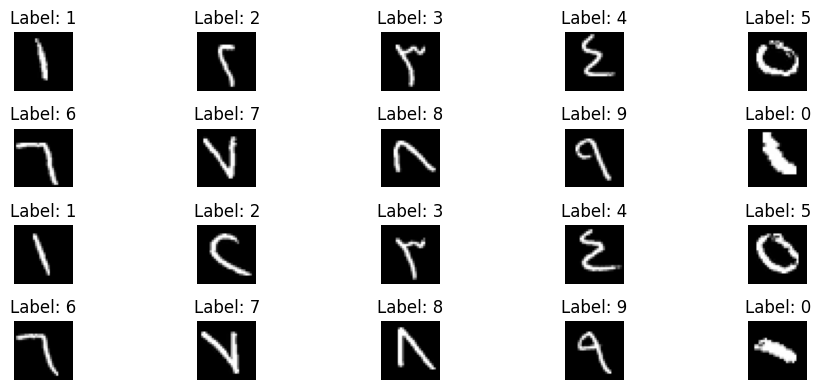

In [ ]:
# 5. Show sample images
plt.figure(figsize=(10, 4))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# 6. Preprocess train/test images
# Normalize pixels from 0-255 to 0-1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Add channel dimension: (samples, 28, 28) -> (samples, 28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode labels because we will use categorical_crossentropy
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

# Detect training image polarity.
# If the average pixel value is high, the dataset is probably black digit on white background.
TRAIN_BACKGROUND_IS_WHITE = float(np.mean(x_train)) > 0.5
print("Training background is white:", TRAIN_BACKGROUND_IS_WHITE)

# Create a validation set manually so we can use optional augmentation cleanly
x_train, x_val, y_train_cat, y_val_cat = train_test_split(
    x_train,
    y_train_cat,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("x_train after split:", x_train.shape)
print("x_val:", x_val.shape)


x_train shape: (59999, 28, 28, 1)
x_test shape: (9999, 28, 28, 1)
y_train_cat shape: (59999, 10)
y_test_cat shape: (9999, 10)
Training background is white: False
x_train after split: (53999, 28, 28, 1)
x_val: (6000, 28, 28, 1)


In [ ]:
# 7. Build normal Neural Network / MLP model
# IMPORTANT: No Conv2D, no MaxPooling2D, only Flatten and Dense layers.
# This is still an MLP, but a little stronger for confusing digits like 0/8 and 5/9.

model = models.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.35),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.25),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.15),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 8. Train model
# EarlyStopping keeps the best validation weights and avoids overfitting.

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train_cat,
    epochs=30,
    batch_size=128,
    validation_data=(x_val, y_val_cat),
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9417 - loss: 0.2092 - val_accuracy: 0.9795 - val_loss: 0.0733
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9810 - loss: 0.0684 - val_accuracy: 0.9827 - val_loss: 0.0690
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9864 - loss: 0.0482 - val_accuracy: 0.9875 - val_loss: 0.0471
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9888 - loss: 0.0378 - val_accuracy: 0.9872 - val_loss: 0.0518
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9902 - loss: 0.0332 - val_accuracy: 0.9867 - val_loss: 0.0452
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9907 - loss: 0.0315 - val_accuracy: 0.9907 - val_loss: 0.0374
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9921 - loss: 0.0267 - val_accuracy: 0.9892 - val_loss: 0.0432
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9925 - loss: 0.0251 - val_ac

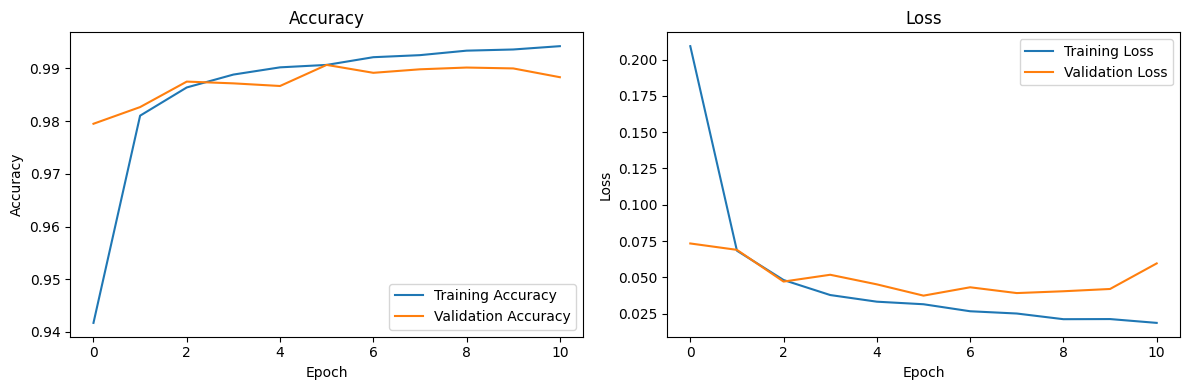

Final training accuracy: 0.994222104549408
Final validation accuracy: 0.9883333444595337


In [ ]:
# 9. Plot training accuracy/loss and validation accuracy/loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])

In [ ]:
# 10. Evaluate model on test set
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 0.05852120742201805
Test accuracy: 0.9849985241889954


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


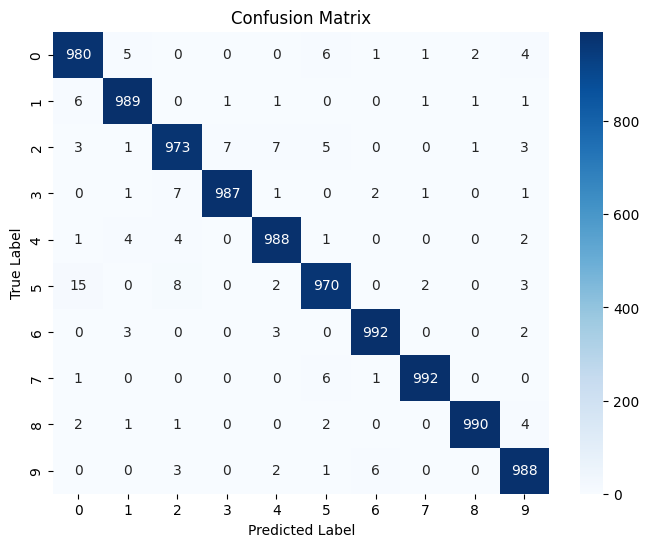

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       999
           1       0.99      0.99      0.99      1000
           2       0.98      0.97      0.97      1000
           3       0.99      0.99      0.99      1000
           4       0.98      0.99      0.99      1000
           5       0.98      0.97      0.97      1000
           6       0.99      0.99      0.99      1000
           7       0.99      0.99      0.99      1000
           8       1.00      0.99      0.99      1000
           9       0.98      0.99      0.98      1000

    accuracy                           0.98      9999
   macro avg       0.99      0.98      0.98      9999
weighted avg       0.99      0.98      0.98      9999



In [ ]:
# 11. Confusion matrix and classification report
y_prob = model.predict(x_test)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print(classification_report(y_test, y_pred))

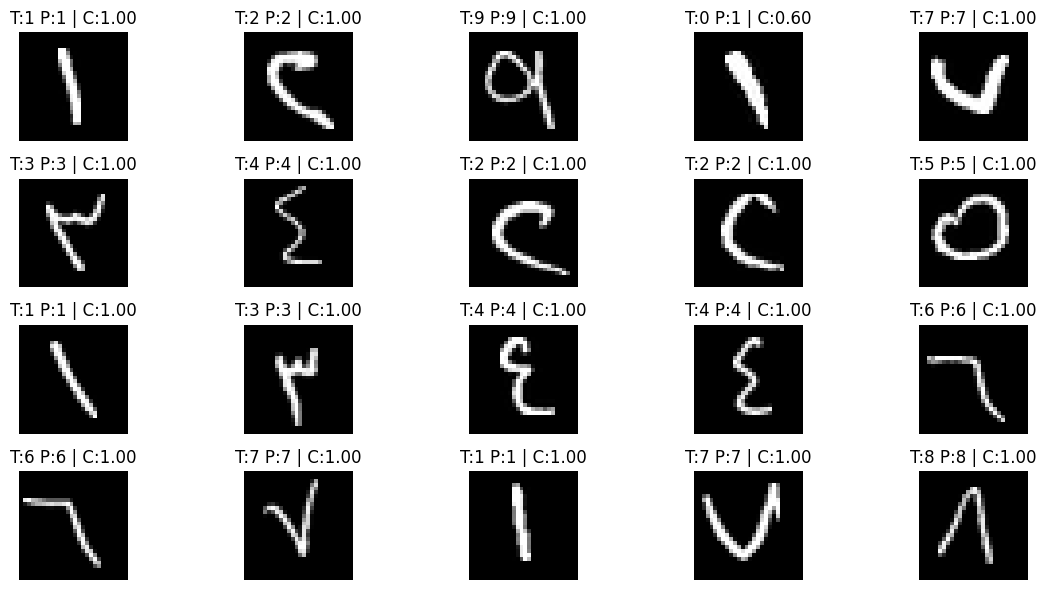

Random sample verification accuracy: 0.95


In [ ]:
# 12. Verify random predictions automatically
random_indices = np.random.choice(len(x_test), size=20, replace=False)
correct_count = 0

plt.figure(figsize=(12, 6))

for i, index in enumerate(random_indices):
    image = x_test[index]
    true_label = y_test[index]

    probabilities = model.predict(image.reshape(1, 28, 28, 1), verbose=0)[0]
    predicted_label = np.argmax(probabilities)
    confidence = np.max(probabilities)

    if predicted_label == true_label:
        correct_count += 1

    plt.subplot(4, 5, i + 1)
    plt.imshow(image.reshape(28, 28), cmap="gray")
    plt.title(f"T:{true_label} P:{predicted_label} | C:{confidence:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

verification_accuracy = correct_count / len(random_indices)
print("Random sample verification accuracy:", verification_accuracy)

In [ ]:
# 13. OpenCV preprocessing and prediction functions for custom images

def create_digit_mask(image_path, use_blue_first=True):
    bgr = cv2.imread(image_path)

    if bgr is None:
        raise ValueError("Image not found: " + image_path)

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    mask = None

    # Useful when digits are written with a blue pen.
    if use_blue_first:
        hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
        lower_blue = np.array([85, 35, 30])
        upper_blue = np.array([145, 255, 255])
        blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)

        blue_pixels = cv2.countNonZero(blue_mask)
        min_blue_pixels = max(20, int(0.00002 * blue_mask.shape[0] * blue_mask.shape[1]))

        if blue_pixels >= min_blue_pixels:
            mask = blue_mask

    if mask is None:
        blur = cv2.GaussianBlur(gray, (5, 5), 0)
        _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel_open = np.ones((2, 2), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)

    kernel_dilate = np.ones((2, 2), np.uint8)
    mask = cv2.dilate(mask, kernel_dilate, iterations=1)

    return rgb, mask


def detect_digit_boxes(mask):
    img_h, img_w = mask.shape
    img_area = img_h * img_w

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    mask2 = cv2.dilate(mask, kernel, iterations=1)

    contours, _ = cv2.findContours(mask2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []

    min_area = max(80, img_area * 0.00008)
    min_h = max(8, img_h * 0.018)
    min_w = max(3, img_w * 0.004)

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = cv2.contourArea(cnt)

        if area < min_area:
            continue

        if w < min_w or h < min_h:
            continue

        if w > img_w * 0.40 or h > img_h * 0.65:
            continue

        if x < 5 or y < 5 or x + w > img_w - 5 or y + h > img_h - 5:
            continue

        boxes.append((x, y, w, h))

    return sorted(boxes, key=lambda b: b[0])


def center_by_mass(image_28):
    ys, xs = np.nonzero(image_28 > 0.05)

    if len(xs) == 0:
        return image_28

    weights = image_28[ys, xs]
    center_x = np.average(xs, weights=weights)
    center_y = np.average(ys, weights=weights)

    shift_x = int(round(14 - center_x))
    shift_y = int(round(14 - center_y))

    transform = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
    shifted = cv2.warpAffine(image_28, transform, (28, 28), borderValue=0)

    return shifted


def match_training_polarity(image_28):
    # The mask creates white digit on black background.
    # If training images have white background, invert the custom digit to match training.
    if TRAIN_BACKGROUND_IS_WHITE:
        return 1.0 - image_28
    return image_28


def preprocess_digit_from_box(mask, box, padding=8, digit_size=20, target_size=28):
    img_h, img_w = mask.shape
    x, y, w, h = box

    x1 = max(x - padding, 0)
    y1 = max(y - padding, 0)
    x2 = min(x + w + padding, img_w)
    y2 = min(y + h + padding, img_h)

    digit = mask[y1:y2, x1:x2]
    coords = cv2.findNonZero(digit)

    if coords is None:
        return None

    dx, dy, dw, dh = cv2.boundingRect(coords)
    digit = digit[dy:dy + dh, dx:dx + dw]

    h_digit, w_digit = digit.shape
    size = max(h_digit, w_digit)
    square = np.zeros((size, size), dtype=np.uint8)

    x_offset = (size - w_digit) // 2
    y_offset = (size - h_digit) // 2
    square[y_offset:y_offset + h_digit, x_offset:x_offset + w_digit] = digit

    resized = cv2.resize(square, (digit_size, digit_size), interpolation=cv2.INTER_AREA)

    final_img = np.zeros((target_size, target_size), dtype=np.float32)
    start = (target_size - digit_size) // 2
    final_img[start:start + digit_size, start:start + digit_size] = resized.astype("float32") / 255.0
    final_img = center_by_mass(final_img)
    final_img = match_training_polarity(final_img)

    model_input = final_img.reshape(1, target_size, target_size, 1).astype("float32")
    return final_img, model_input


def predict_digit_keras(model_input, model):
    prediction = model.predict(model_input, verbose=0)
    digit = int(np.argmax(prediction))
    confidence = float(np.max(prediction))
    return digit, confidence, prediction


def preprocess_single_digit_image(image_path, show_steps=True):
    rgb, mask = create_digit_mask(image_path)
    boxes = detect_digit_boxes(mask)

    if len(boxes) == 0:
        raise ValueError("No digit detected")

    selected_box = sorted(boxes, key=lambda b: b[2] * b[3], reverse=True)[0]
    result = preprocess_digit_from_box(mask, selected_box)

    if result is None:
        raise ValueError("Could not preprocess the detected digit")

    final_img, model_input = result

    if show_steps:
        debug_img = rgb.copy()
        x, y, w, h = selected_box
        cv2.rectangle(debug_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(debug_img)
        plt.title("Detected Digit")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(mask, cmap="gray")
        plt.title("Mask")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(final_img, cmap="gray")
        plt.title("Model Input")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    return final_img, model_input


def predict_multiple_digits_keras(image_path, model, show_steps=True):
    rgb, mask = create_digit_mask(image_path)
    boxes = detect_digit_boxes(mask)

    if len(boxes) == 0:
        print("No digits detected.")
        return "", [], []

    predicted_digits = []
    confidences = []
    all_probabilities = []
    processed_digits = []

    image_with_boxes = rgb.copy()

    for box in boxes:
        x, y, w, h = box

        result = preprocess_digit_from_box(mask, box)
        if result is None:
            continue

        final_img, model_input = result
        digit, confidence, prediction = predict_digit_keras(model_input, model)

        predicted_digits.append(str(digit))
        confidences.append(confidence)
        all_probabilities.append(prediction[0])
        processed_digits.append(final_img)

        cv2.rectangle(image_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(
            image_with_boxes,
            f"{digit}:{confidence:.2f}",
            (x, max(15, y - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 255, 0),
            2,
            cv2.LINE_AA,
        )

    final_prediction = "".join(predicted_digits)

    if show_steps:
        plt.figure(figsize=(8, 5))
        plt.imshow(image_with_boxes)
        plt.axis("off")
        plt.title(f"Detected Boxes\nFinal Prediction: {final_prediction}", fontsize=16)
        plt.show()

        plt.figure(figsize=(max(1, len(processed_digits)) * 1.6, 2.2))
        for i, digit_img in enumerate(processed_digits):
            plt.subplot(1, len(processed_digits), i + 1)
            plt.imshow(digit_img, cmap="gray")
            plt.title(f"{predicted_digits[i]}\n{confidences[i]:.2f}")
            plt.axis("off")
        plt.tight_layout()
        plt.show()

    print("Final Prediction:", final_prediction)
    print("Predicted digits:", predicted_digits)
    print("Confidences:", [round(c, 4) for c in confidences])

    for i, probabilities in enumerate(all_probabilities):
        print(f"Digit {i + 1} probabilities:", np.round(probabilities, 4))

    return final_prediction, predicted_digits, confidences


Saving image.png to image.png


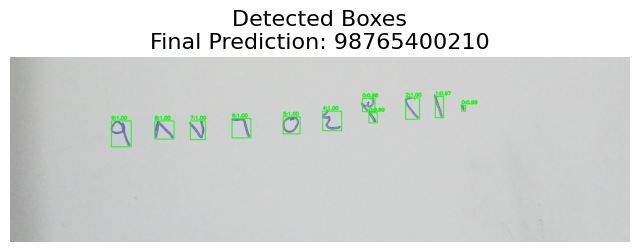

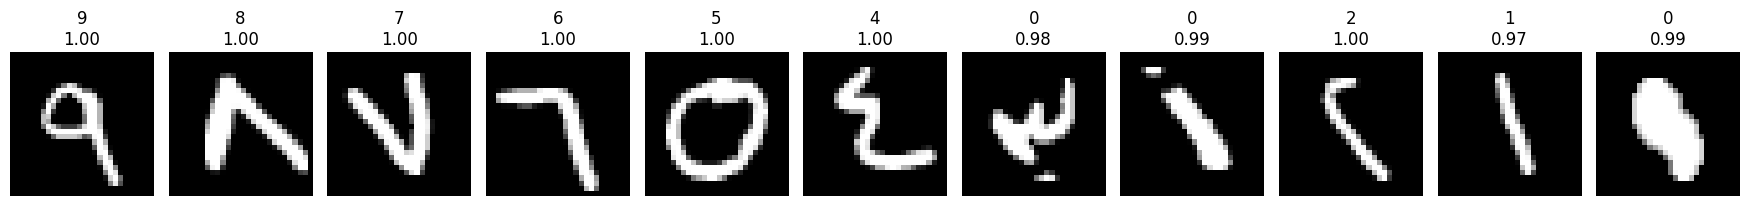

Final Prediction: 98765400210
Predicted digits: ['9', '8', '7', '6', '5', '4', '0', '0', '2', '1', '0']
Confidences: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9757, 0.9874, 0.9993, 0.9738, 0.9915]
Digit 1 probabilities: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
Digit 2 probabilities: [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
Digit 3 probabilities: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Digit 4 probabilities: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Digit 5 probabilities: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Digit 6 probabilities: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
Digit 7 probabilities: [9.757e-01 5.000e-04 0.000e+00 1.780e-02 0.000e+00 1.700e-03 0.000e+00
 4.000e-03 2.000e-04 1.000e-04]
Digit 8 probabilities: [9.874e-01 8.100e-03 0.000e+00 2.000e-04 0.000e+00 1.400e-03 1.000e-04
 6.000e-04 1.800e-03 3.000e-04]
Digit 9 probabilities: [0.000e+00 0.000e+00 9.993e-01 5.000e-04 1.000e-04 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00]
Digit 10 probabilities: [0.0077 0.9738 0.     0.     0.     0.     0.0067 0.     0.0081 0.0037]
Digit 11

In [ ]:


try:
    from google.colab import files
    uploaded = files.upload()
    image_path = list(uploaded.keys())[0]
except ModuleNotFoundError:
    image_path = "test.jpg"

final_prediction, predicted_digits, confidences = predict_multiple_digits_keras(
    image_path,
    model,
    show_steps=True
)


In [ ]:
# 15. Save Keras model
keras_model_path = "arabic_digit_mlp_model.keras"
model.save(keras_model_path)

print("Saved Keras model:", keras_model_path)

Saved Keras model: arabic_digit_mlp_model.keras


In [ ]:
# 16. Convert model to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_model_path = "arabic_digit_mlp_model.tflite"

with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)

print("Saved TFLite model:", tflite_model_path)

Saved artifact at '/tmp/tmpqub2k6lz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139478282201872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139478282203984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139478282204944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139478282204560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139478282202640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139478282204368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139478282205136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139478282202832: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved TFLite model: arabic_digit_mlp_model.tflite


In [ ]:
# 17. Test TFLite model in Colab
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("TFLite input details:", input_details)
print("TFLite output details:", output_details)

print("TFLite input shape:", input_details[0]["shape"])
print("TFLite output shape:", output_details[0]["shape"])

assert list(input_details[0]["shape"]) == [1, 28, 28, 1]
assert list(output_details[0]["shape"]) == [1, 10]
print("TFLite shapes are compatible with Android app.")

# Test one image from the test set
test_image = x_test[0].reshape(1, 28, 28, 1).astype("float32")
true_label = y_test[0]

interpreter.set_tensor(input_details[0]["index"], test_image)
interpreter.invoke()

tflite_output = interpreter.get_tensor(output_details[0]["index"])
tflite_prediction = np.argmax(tflite_output[0])
tflite_confidence = np.max(tflite_output[0])

print("True label:", true_label)
print("TFLite predicted label:", tflite_prediction)
print("TFLite confidence:", tflite_confidence)
print("TFLite probabilities:", tflite_output[0])

TFLite input details: [{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([ 1, 28, 28,  1], dtype=int32), 'shape_signature': array([-1, 28, 28,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
TFLite output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 20, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
TFLite input shape: [ 1 28 28  1]
TFLite output shape: [ 1 10]
TFLite shapes are compatible with Android app.
True label: 1
TFLite predicted label: 1
TFLite confidence: 0.99945956
TFLite probabilities: [5.0156028e-04 

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# 18. Download models from Colab, or show saved paths in local Jupyter
try:
    from google.colab import files
    files.download(keras_model_path)
    files.download(tflite_model_path)
except ModuleNotFoundError:
    print("Models are saved in the current notebook folder:")
    print(keras_model_path)
    print(tflite_model_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>